<a href="https://colab.research.google.com/github/jiissung/ECON3916-Statistical-Machine-Learning/blob/main/Project%201/%5BProject_1%5D_Phase_4_Final_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [266]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor


df = pd.read_csv("public.csv")

codebook_names = [
"SHEET","CHAIN","CO_OWNED","STATE","SOUTHJ","CENTRALJ","NORTHJ","PA1","PA2","SHORE",
"NCALLS","EMPFT","EMPPT","NMGRS","WAGE_ST","INCTIME","FIRSTINC","BONUS","PCTAFF","MEALS",
"OPEN","HRSOPEN","PSODA","PFRY","PENTREE","NREGS","NREGS11","TYPE2","STATUS2","DATE2",
"NCALLS2","EMPFT2","EMPPT2","NMGRS2","WAGE_ST2","INCTIME2","FIRSTIN2","SPECIAL2","MEALS2",
"OPEN2R","HRSOPEN2","PSODA2","PFRY2","PENTREE2","NREGS2","NREGS112"
]

df.columns = codebook_names

df['WAGE_ST'] = df['WAGE_ST'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

In [267]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

print(missing_percent.sort_values(ascending=False))
df = df.dropna()

NCALLS2     60.731707
FIRSTIN2    19.512195
INCTIME2    16.097561
PCTAFF      10.731707
FIRSTINC    10.487805
INCTIME      7.560976
PFRY2        6.829268
NREGS112     6.585366
PENTREE2     5.853659
PSODA2       5.365854
NREGS2       5.365854
WAGE_ST2     5.121951
WAGE_ST      4.878049
SPECIAL2     4.390244
PFRY         4.146341
NREGS11      2.926829
EMPFT2       2.926829
PENTREE      2.926829
OPEN2R       2.682927
HRSOPEN2     2.682927
MEALS2       2.682927
EMPPT2       2.439024
PSODA        1.951220
EMPFT        1.463415
NMGRS2       1.463415
NREGS        1.463415
NMGRS        1.463415
EMPPT        0.975610
CO_OWNED     0.000000
SHEET        0.000000
NCALLS       0.000000
PA1          0.000000
PA2          0.000000
SHORE        0.000000
NORTHJ       0.000000
STATE        0.000000
SOUTHJ       0.000000
CENTRALJ     0.000000
CHAIN        0.000000
DATE2        0.000000
TYPE2        0.000000
STATUS2      0.000000
BONUS        0.000000
MEALS        0.000000
OPEN         0.000000
HRSOPEN   

In [268]:
variables = ["PENTREE", "WAGE_ST", "EMPFT", "EMPPT", "CHAIN"]

nj_stats = df[df["STATE"] == 1][variables].agg(["mean", "std"]).T
pa_stats = df[df["STATE"] == 0][variables].agg(["mean", "std"]).T

table1 = pd.DataFrame({
    "NJ Mean": nj_stats["mean"],
    "NJ Std": nj_stats["std"],
    "PA Mean": pa_stats["mean"],
    "PA Std": pa_stats["std"]
}).round(3)

print("Summary Statistics by State")
print(table1)

Summary Statistics by State
         NJ Mean  NJ Std  PA Mean  PA Std
PENTREE    1.609   0.753    1.116   0.491
WAGE_ST    4.630   0.306    4.721   0.313
EMPFT      7.458   7.707    9.125   8.876
EMPPT     16.583  10.289   21.800   9.754
CHAIN      2.167   0.953    2.250   1.293


In [269]:
formula_1 = 'np.log(PENTREE) ~ WAGE_ST + C(CHAIN) + SOUTHJ + CENTRALJ + NORTHJ + PA1 + PA2'
model_1 = smf.ols(formula=formula_1, data=df).fit(cov_type='HC1')
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:        np.log(PENTREE)   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     161.6
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.68e-38
Time:                        00:39:25   Log-Likelihood:                 29.195
No. Observations:                  68   AIC:                            -40.39
Df Residuals:                      59   BIC:                            -20.41
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.2613      0.266     -0.981

In [270]:
formula_interact = 'np.log(PENTREE) ~ WAGE_ST * C(CHAIN) + SOUTHJ + CENTRALJ + NORTHJ + PA1 + PA2'
model_interact = smf.ols(formula=formula_interact, data=df).fit(cov_type='HC1')
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:        np.log(PENTREE)   R-squared:                       0.884
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     184.4
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           2.03e-40
Time:                        00:39:25   Log-Likelihood:                 31.097
No. Observations:                  68   AIC:                            -38.19
Df Residuals:                      56   BIC:                            -11.56
Df Model:                          11                                         
Covariance Type:                  HC1                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.02

In [271]:
fitted_vals = model_interact.fittedvalues
residuals = model_interact.resid

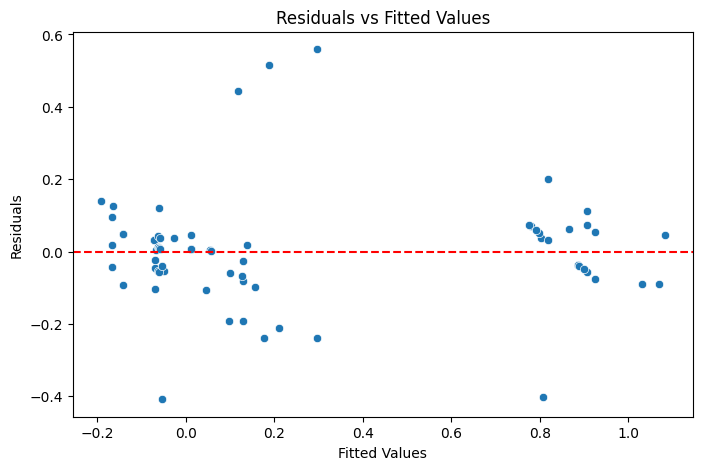

In [272]:
# Residuals vs
plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

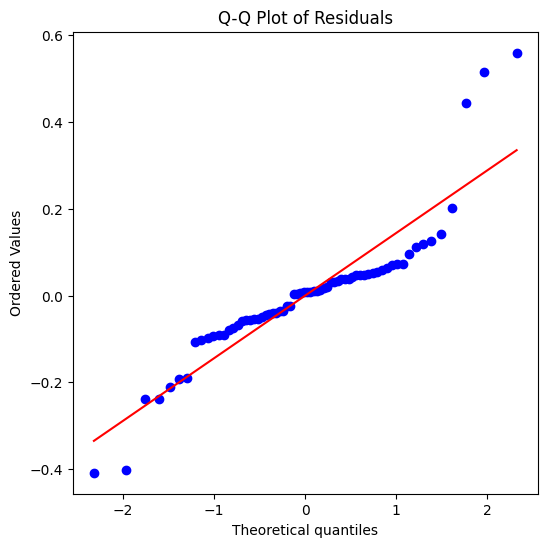

In [273]:
plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [274]:
# HTC Test
X = model_interact.model.exog

white_test = het_white(residuals, X)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, white_test)))

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, white_test)))

{'LM Statistic': np.float64(50.817479443873324), 'LM-Test p-value': np.float64(0.051773655923710964), 'F-Statistic': np.float64(2.546744876273506), 'F-Test p-value': np.float64(0.004738205139757124)}
{'LM Statistic': np.float64(50.817479443873324), 'LM-Test p-value': np.float64(0.051773655923710964), 'F-Statistic': np.float64(2.546744876273506), 'F-Test p-value': np.float64(0.004738205139757124)}


In [275]:
# Initial VIF Results

vif_data = pd.DataFrame()
vif_data["Feature"] = model_interact.model.exog_names
vif_data["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

print(vif_data)

                  Feature         VIF
0               Intercept    0.000000
1           C(CHAIN)[T.2]  360.976708
2           C(CHAIN)[T.3]  346.098542
3           C(CHAIN)[T.4]  336.588885
4                 WAGE_ST    4.561352
5   WAGE_ST:C(CHAIN)[T.2]  369.716024
6   WAGE_ST:C(CHAIN)[T.3]  348.149713
7   WAGE_ST:C(CHAIN)[T.4]  338.015587
8                  SOUTHJ         inf
9                CENTRALJ         inf
10                 NORTHJ         inf
11                    PA1         inf
12                    PA2         inf


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [276]:
# New Model

df = df.drop(columns=['SOUTHJ'])
formula_1 = 'np.log(PENTREE) ~ WAGE_ST + C(CHAIN) + CENTRALJ + NORTHJ + PA1 + PA2'
model_1 = smf.ols(formula=formula_1, data=df).fit(cov_type='HC1')
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:        np.log(PENTREE)   R-squared:                       0.878
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     120.4
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.26e-33
Time:                        00:39:25   Log-Likelihood:                 29.195
No. Observations:                  68   AIC:                            -40.39
Df Residuals:                      59   BIC:                            -20.41
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.4149      0.327     -1.268

In [277]:
# VIF
X = model_1.model.exog

vif_data = pd.DataFrame()
vif_data["Feature"] = model_1.model.exog_names
vif_data["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]

print(vif_data)

         Feature         VIF
0      Intercept  263.877869
1  C(CHAIN)[T.2]    1.592693
2  C(CHAIN)[T.3]    1.359890
3  C(CHAIN)[T.4]    1.407416
4        WAGE_ST    1.215273
5       CENTRALJ    1.644466
6         NORTHJ    2.137262
7            PA1    1.735661
8            PA2    2.151316


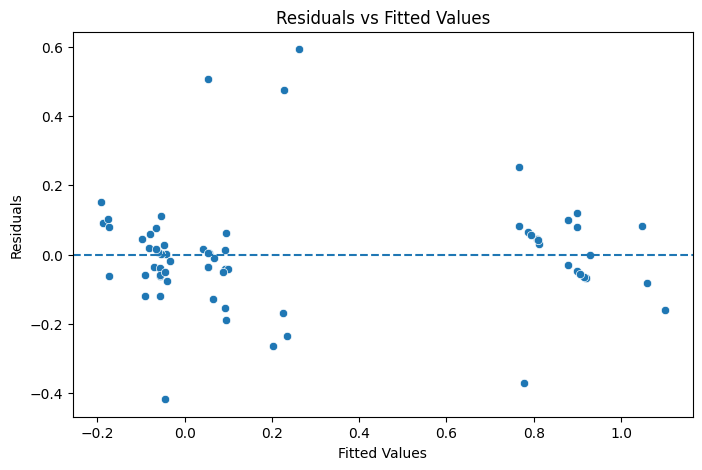

In [278]:
# Residuals
fitted_vals = model_1.fittedvalues
residuals = model_1.resid


plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

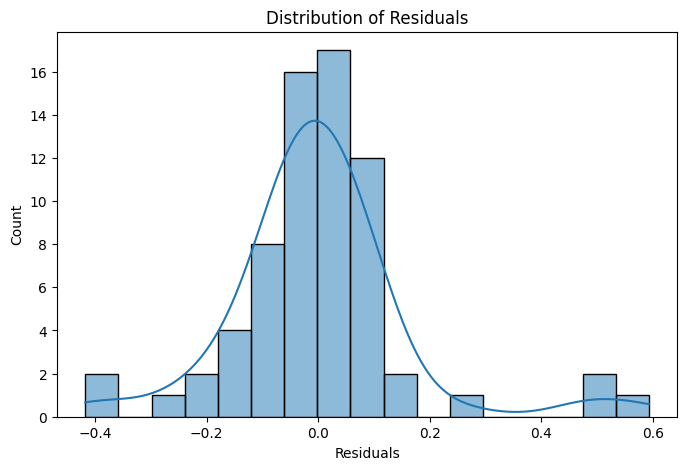

In [279]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.show()

In [280]:
X = model_1.model.exog

white_test = het_white(residuals, X)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, white_test)))

{'LM Statistic': np.float64(52.027719612305965), 'LM-Test p-value': np.float64(0.0026320655317026106), 'F-Statistic': np.float64(4.825741926539656), 'F-Test p-value': np.float64(4.049971605143714e-06)}
